In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
games = pd.read_csv("cleaned_games.csv")

sales = pd.read_csv("cleaned_vgsales.csv")

merged = pd.read_csv("merged_games_sales.csv")

In [3]:
games_clean = games.copy()

sales_clean = sales.copy()

merged_clean = merged.copy()

In [ ]:
#1 top-rated games by user reviews?
top_rated = games_clean[['Title', 'Rating']].sort_values(
    by='Rating',
    ascending=False
).head(10)

top_rated

,Title,Rating
1252,Elden Ring: Shadow of the Erdtree,4.8
1322,Bloodborne: Game of the Year Edition,4.6
297,Bloodborne: The Old Hunters,4.6
43,Outer Wilds,4.6
1286,Tokyo Necro,4.6
354,Disco Elysium: The Final Cut,4.6
369,Outer Wilds,4.6
428,Disco Elysium,4.6
1138,Half-Life: Alyx,4.6
539,Umineko: When They Cry Chiru,4.6


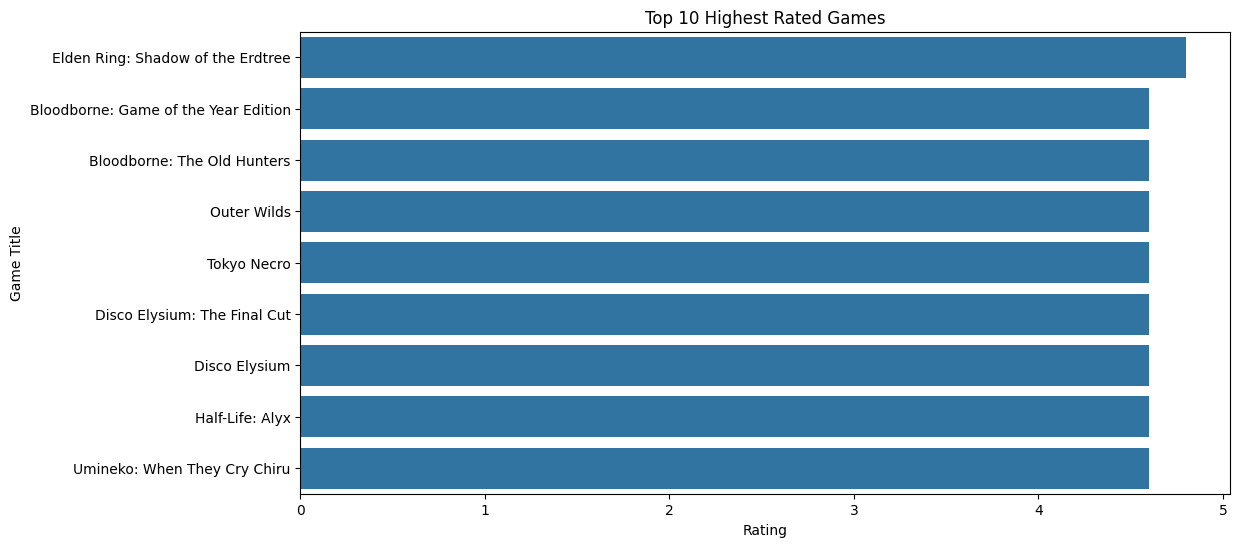

In [5]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rated,
    x='Rating',
    y='Title'
)

plt.title("Top 10 Highest Rated Games")

plt.xlabel("Rating")

plt.ylabel("Game Title")

plt.show()

In [ ]:
#2 developers (Teams) have the highest average ratings?
developer_ratings = games_clean.groupby('Team')['Rating'].mean().sort_values(
    ascending=False
).head(10)

developer_ratings

Team
['07th Expansion']                                 4.600
['Activision', 'FromSoftware']                     4.600
['Valve']                                          4.600
['Sony Computer Entertainment', 'FromSoftware']    4.600
['Bay 12 Games', 'Kitfox Games']                   4.600
['ZA/UM']                                          4.600
['Konami Digital Entertainment']                   4.600
['Inlusio Interactive', 'IO Interactive']          4.600
['Mobius Digital', 'Annapurna Interactive']        4.575
['FromSoftware', 'Sony Computer Entertainment']    4.540
Name: Rating, dtype: float64

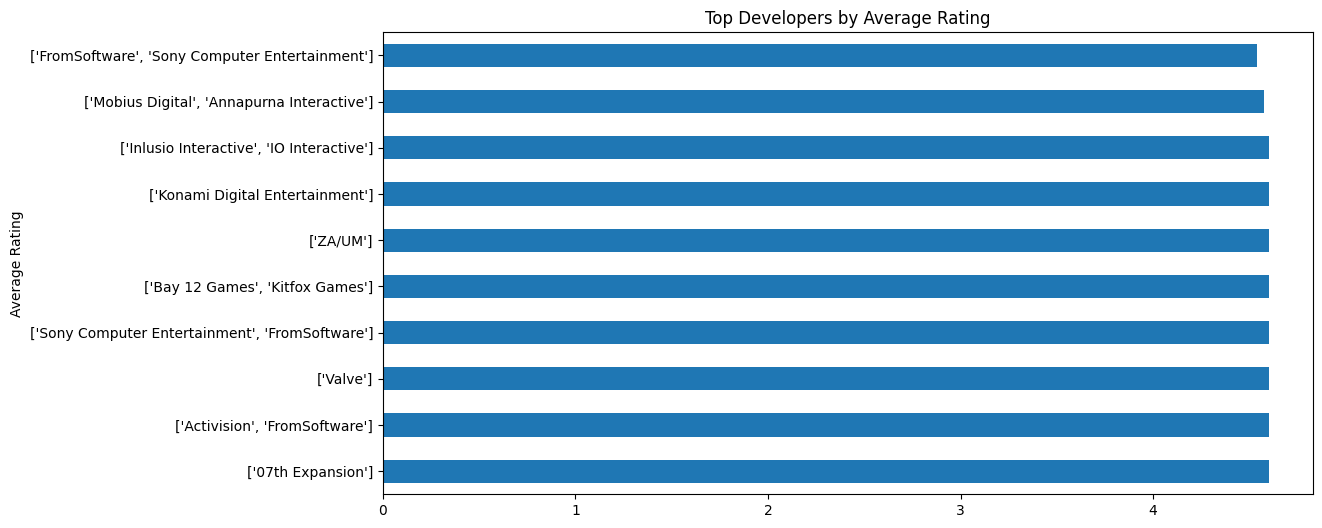

In [8]:
plt.figure(figsize=(12,6))

developer_ratings.plot(kind='barh')

plt.title("Top Developers by Average Rating")

plt.ylabel("Average Rating")

plt.show()

In [ ]:
# Q3. What are the most common genres in the dataset?
games_clean['Genres'].value_counts().head(10)

Genres
['Adventure', 'RPG']                           154
['Adventure', 'Platform']                      107
['Adventure', 'Shooter']                        82
['Shooter']                                     72
['Adventure', 'RPG', 'Turn Based Strategy']     48
['Adventure']                                   44
['Adventure', 'Brawler']                        40
['RPG']                                         37
['Platform']                                    34
['Adventure', 'RPG', 'Shooter']                 34
Name: count, dtype: int64

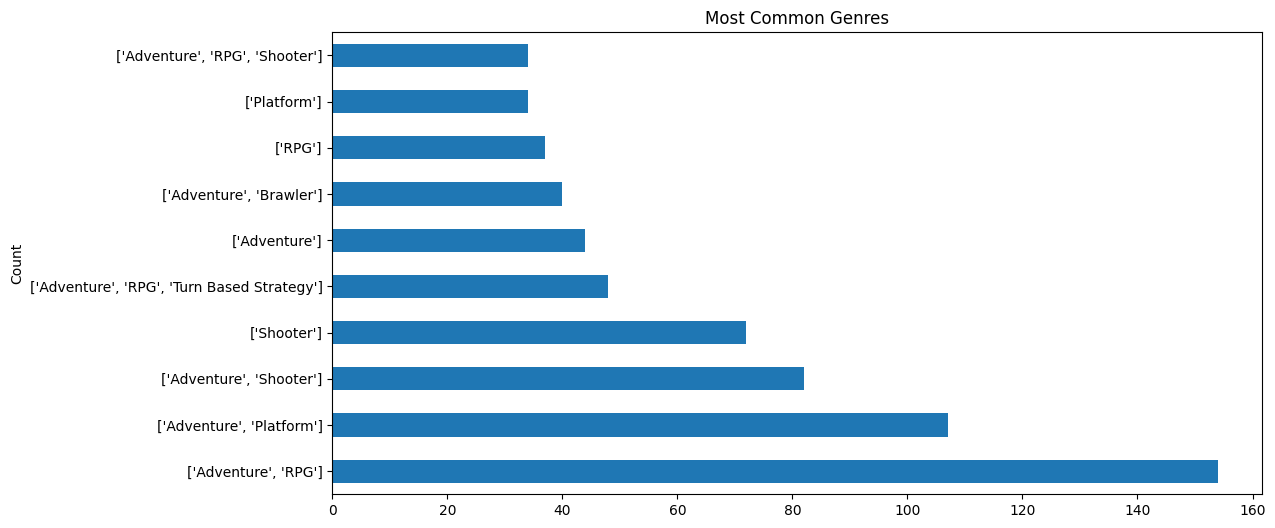

In [11]:
plt.figure(figsize=(12,6))

games_clean['Genres'].value_counts().head(10).plot(kind='barh')

plt.title("Most Common Genres")

plt.ylabel("Count")

plt.show()

In [37]:
## Q4. Which games have the highest backlog compared to wishlist?
games['Backlog_Wishlist_Ratio'] = (
    games['Backlogs'] / games['Wishlist']
)

ratio_games = games[
    ['Title', 'Backlog_Wishlist_Ratio']
].sort_values(
    by='Backlog_Wishlist_Ratio',
    ascending=False
).head(10)

ratio_games

,Title,Backlog_Wishlist_Ratio
661,Paladins,11.750000
1289,Figment,11.200000
842,Fortnite,10.000000
959,Pokémon Go,8.954545
727,Half-Life: Opposing Force,8.821053
1023,Destiny 2,8.203883
1053,Brawlhalla,8.166667
1119,BioShock 2 Remastered,8.130081
1129,Borderlands: The Pre-Sequel,7.983193
1201,PUBG: Battlegrounds,7.906250


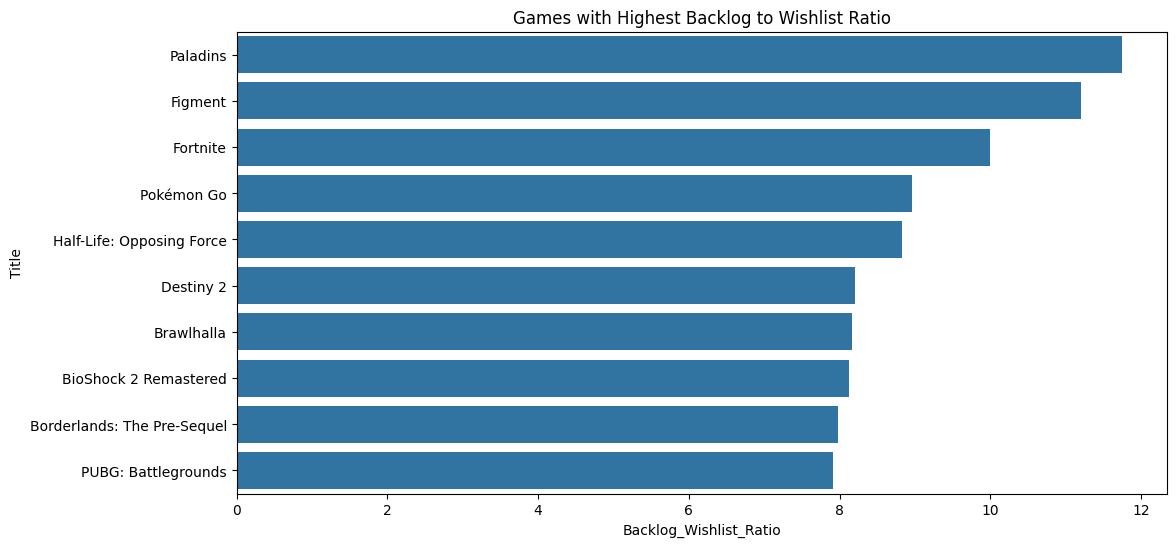

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=ratio_games,
    x='Backlog_Wishlist_Ratio',
    y='Title'
)

plt.title("Games with Highest Backlog to Wishlist Ratio")

plt.show()

In [ ]:
## Q5. What is the game release trend across years?
release_trend = games_clean['Release_Year'].value_counts().sort_index()

release_trend

Release_Year
1980      1
1982      1
1985      1
1986      4
1987      3
1988      5
1989      5
1990      6
1991     11
1992      6
1993     12
1994     11
1995     12
1996     15
1997     18
1998     16
1999     25
2000     18
2001     30
2002     22
2003     26
2004     37
2005     41
2006     32
2007     50
2008     44
2009     40
2010     58
2011     50
2012     60
2013     68
2014     59
2015     73
2016     75
2017     70
2018     77
2019     87
2020     74
2021     97
2022    132
2023     38
2024      1
2025      1
Name: count, dtype: int64

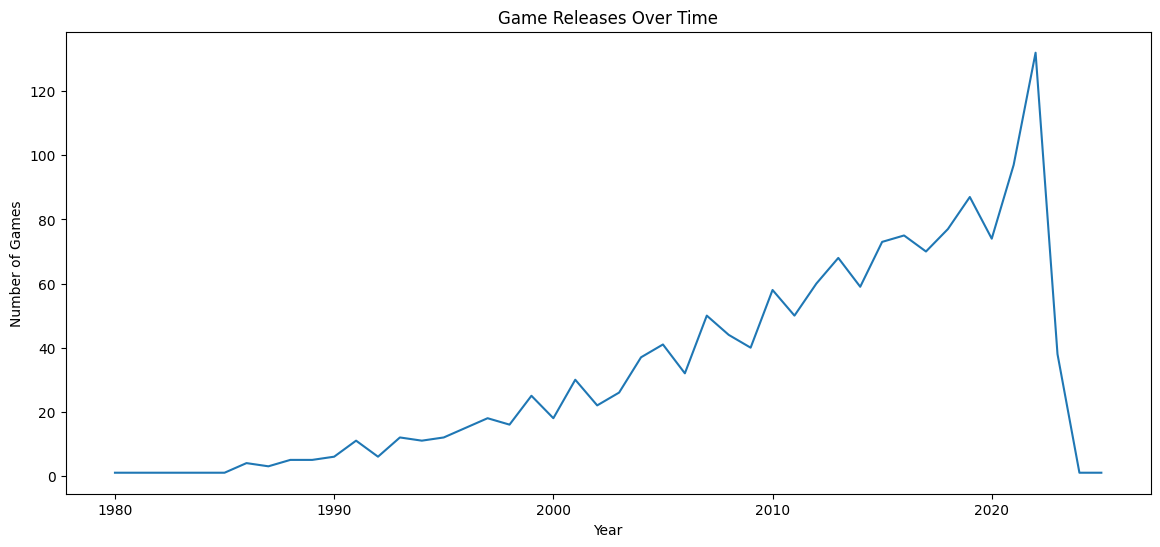

In [15]:
plt.figure(figsize=(14,6))

release_trend.plot(kind='line')

plt.title("Game Releases Over Time")

plt.xlabel("Year")

plt.ylabel("Number of Games")

plt.show()

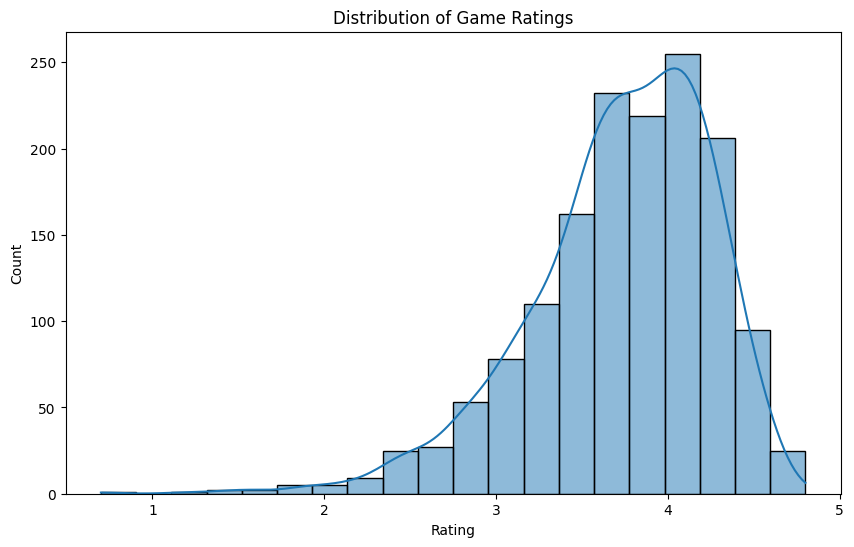

In [ ]:
## Q6. What is the distribution of user ratings?
plt.figure(figsize=(10,6))

sns.histplot(
    games_clean['Rating'],
    bins=20,
    kde=True
)

plt.title("Distribution of Game Ratings")

plt.show()

In [ ]:
## Q7. What are the top 10 most wishlisted games?
genre_plays = games_clean.groupby('Genres')['Plays'].mean().sort_values(
    ascending=False
).head(10)

genre_plays

Genres
['Platform', 'Puzzle', 'Shooter']                                        21750.000000
['Adventure', 'Platform', 'Puzzle', 'Shooter']                           19242.857143
['Adventure', 'Indie', 'Platform', 'RPG', 'Strategy']                    18000.000000
['Arcade', 'Indie', 'Platform', 'Shooter']                               18000.000000
['Indie', 'Racing', 'Sport']                                             17000.000000
['Indie', 'Platform', 'Sport']                                           16000.000000
['Fighting', 'Platform']                                                 15720.000000
['Indie', 'Strategy']                                                    15150.000000
['Puzzle', 'Real Time Strategy', 'Simulator', 'Strategy', 'Tactical']    14000.000000
['Adventure', 'Brawler', 'Shooter', 'Strategy']                          14000.000000
Name: Plays, dtype: float64

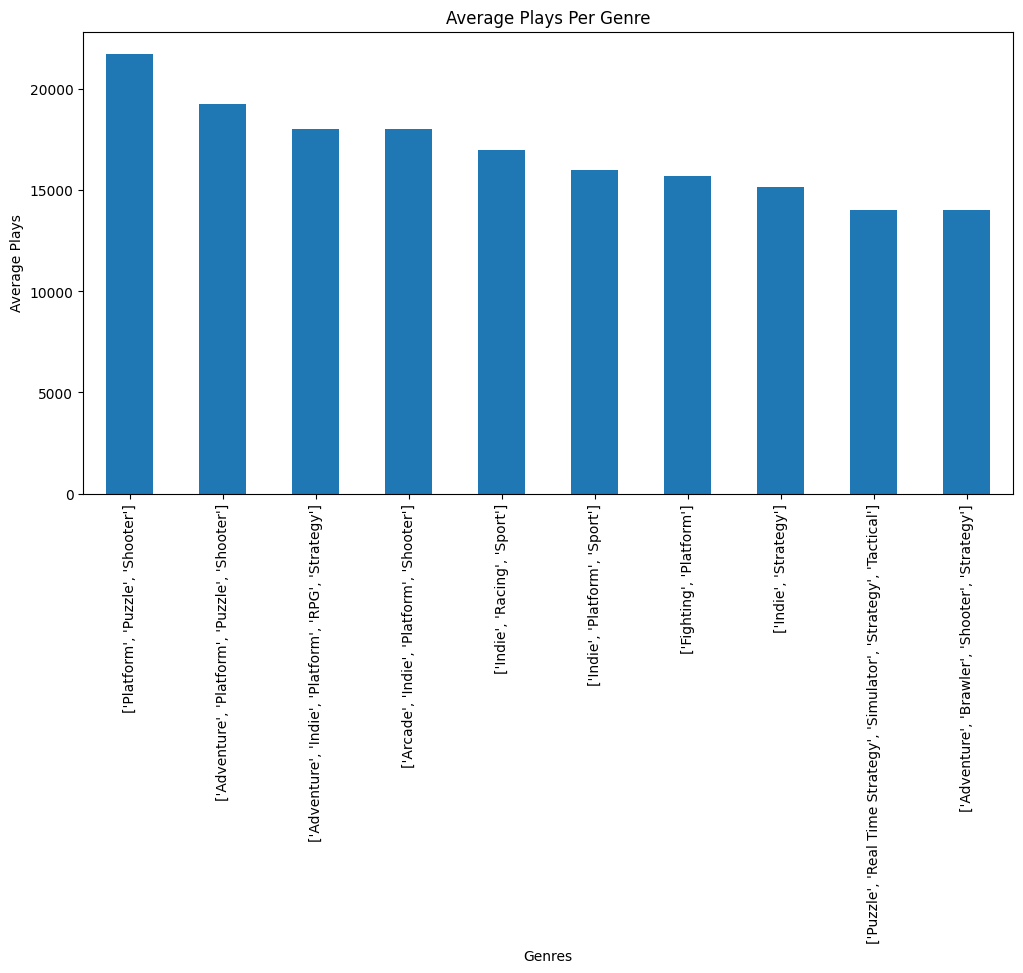

In [35]:
plt.figure(figsize=(12,6))

genre_plays.plot(kind='bar')

plt.title("Average Plays Per Genre")

plt.ylabel("Average Plays")

plt.show()

In [ ]:
## Q8. What’s the average number of plays per genre?
platform_sales = sales_clean.groupby('Platform')['Global_Sales'].sum().sort_values(
    ascending=False
).head(10)

platform_sales

Platform
PS2     1255.64
X360     979.96
PS3      957.84
Wii      926.71
DS       822.49
PS       730.66
GBA      318.50
PSP      296.28
PS4      278.10
PC       258.82
Name: Global_Sales, dtype: float64

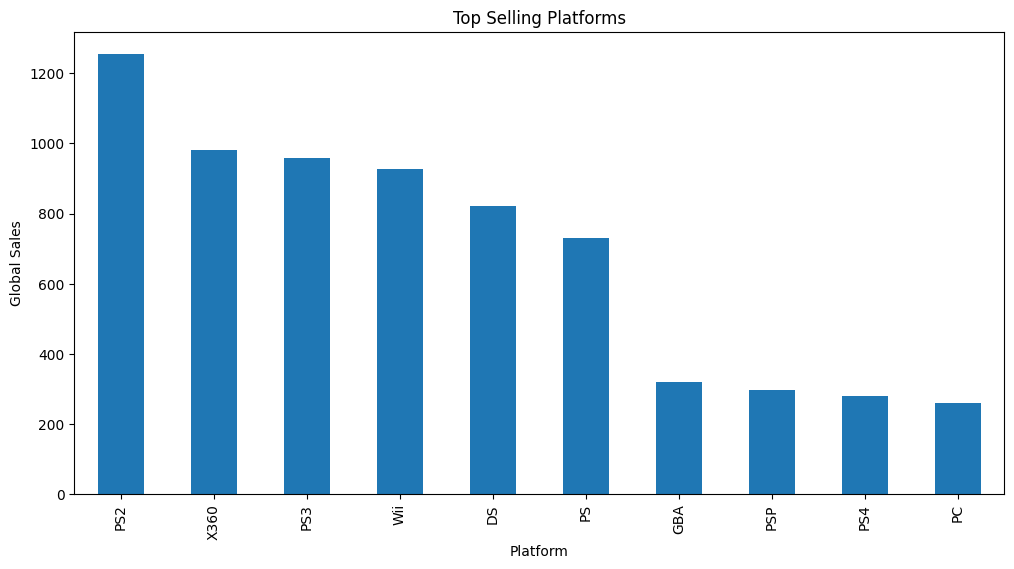

In [34]:
plt.figure(figsize=(12,6))

platform_sales.plot(kind='bar')

plt.title("Top Selling Platforms")

plt.ylabel("Global Sales")

plt.show()

In [39]:
## Q9. Which developer studios are the most productive and impactful?
publisher_sales = sales_clean.groupby('Publisher')['Global_Sales'].sum().sort_values(
    ascending=False
).head(10)

publisher_sales

Publisher
Nintendo                        1786.56
Electronic Arts                 1110.32
Activision                       727.46
Sony Computer Entertainment      607.50
Ubisoft                          474.72
Take-Two Interactive             399.54
THQ                              340.77
Konami Digital Entertainment     283.64
Sega                             272.99
Namco Bandai Games               254.09
Name: Global_Sales, dtype: float64

Sales question

In [40]:
## Q10. Which region generates the most game sales?
regional_sales = sales[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
].sum()

regional_sales

NA_Sales       4392.95
EU_Sales       2434.13
JP_Sales       1291.02
Other_Sales     797.75
dtype: float64

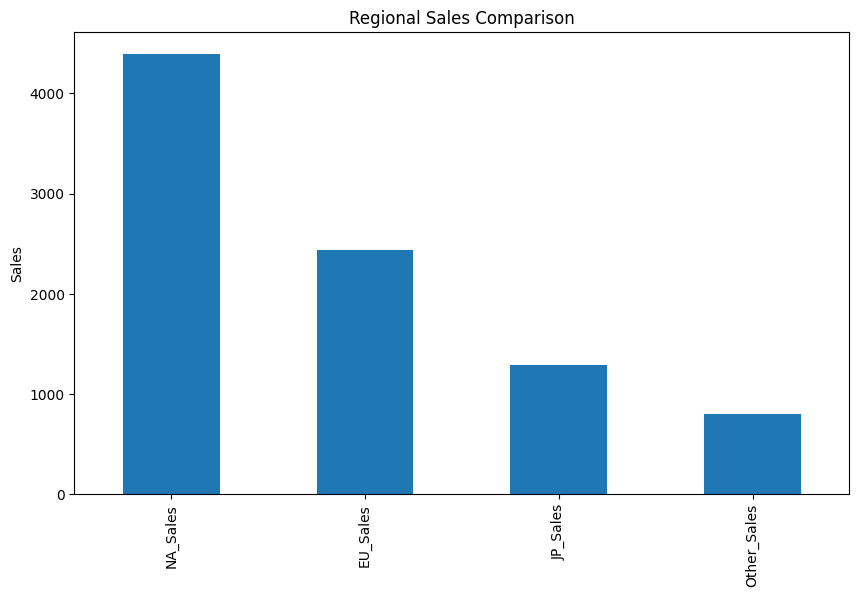

In [41]:
regional_sales.plot(kind='bar', figsize=(10,6))

plt.title("Regional Sales Comparison")

plt.ylabel("Sales")

plt.show()

In [42]:
## Q11. What are the best-selling platforms?
platform_sales = sales_clean.groupby('Platform')['Global_Sales'].sum().sort_values(
    ascending=False
).head(10)

platform_sales

Platform
PS2     1255.64
X360     979.96
PS3      957.84
Wii      926.71
DS       822.49
PS       730.66
GBA      318.50
PSP      296.28
PS4      278.10
PC       258.82
Name: Global_Sales, dtype: float64

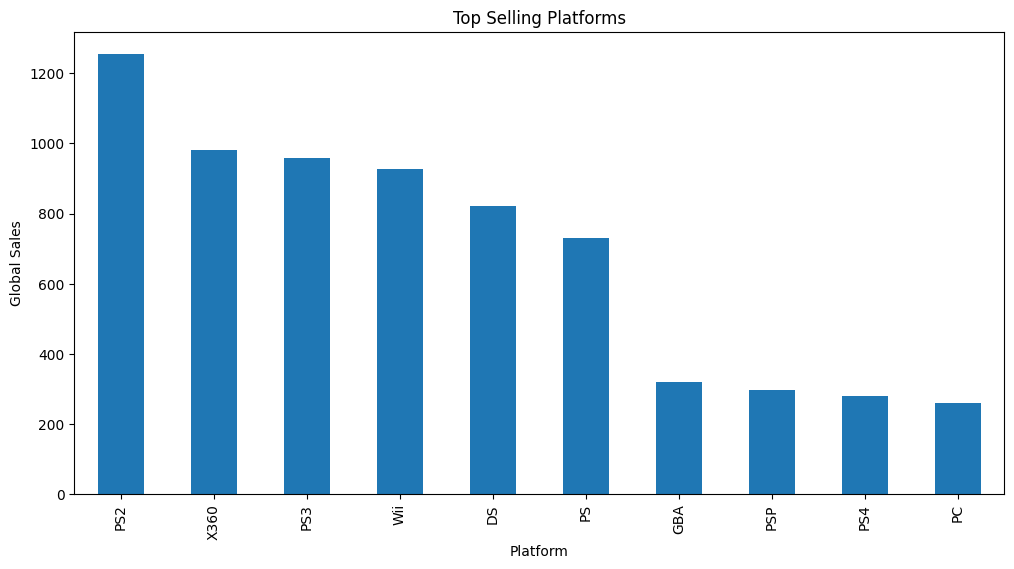

In [43]:
plt.figure(figsize=(12,6))

platform_sales.plot(kind='bar')

plt.title("Top Selling Platforms")

plt.ylabel("Global Sales")

plt.show()

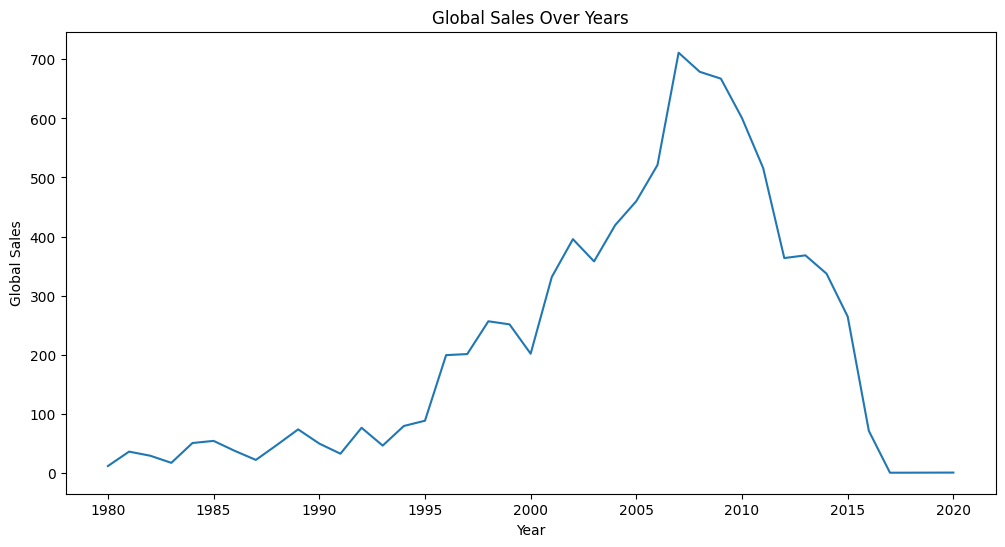

In [44]:
## Q12. What’s the trend of game releases and sales over years?
yearly_sales = sales.groupby('Year')['Global_Sales'].sum()

yearly_sales.plot(figsize=(12,6))

plt.title("Global Sales Over Years")

plt.ylabel("Global Sales")

plt.show()

In [45]:
## Q13. Who are the top publishers by sales?
publisher_sales = sales_clean.groupby('Publisher')['Global_Sales'].sum().sort_values(
    ascending=False
).head(10)

publisher_sales

Publisher
Nintendo                        1786.56
Electronic Arts                 1110.32
Activision                       727.46
Sony Computer Entertainment      607.50
Ubisoft                          474.72
Take-Two Interactive             399.54
THQ                              340.77
Konami Digital Entertainment     283.64
Sega                             272.99
Namco Bandai Games               254.09
Name: Global_Sales, dtype: float64

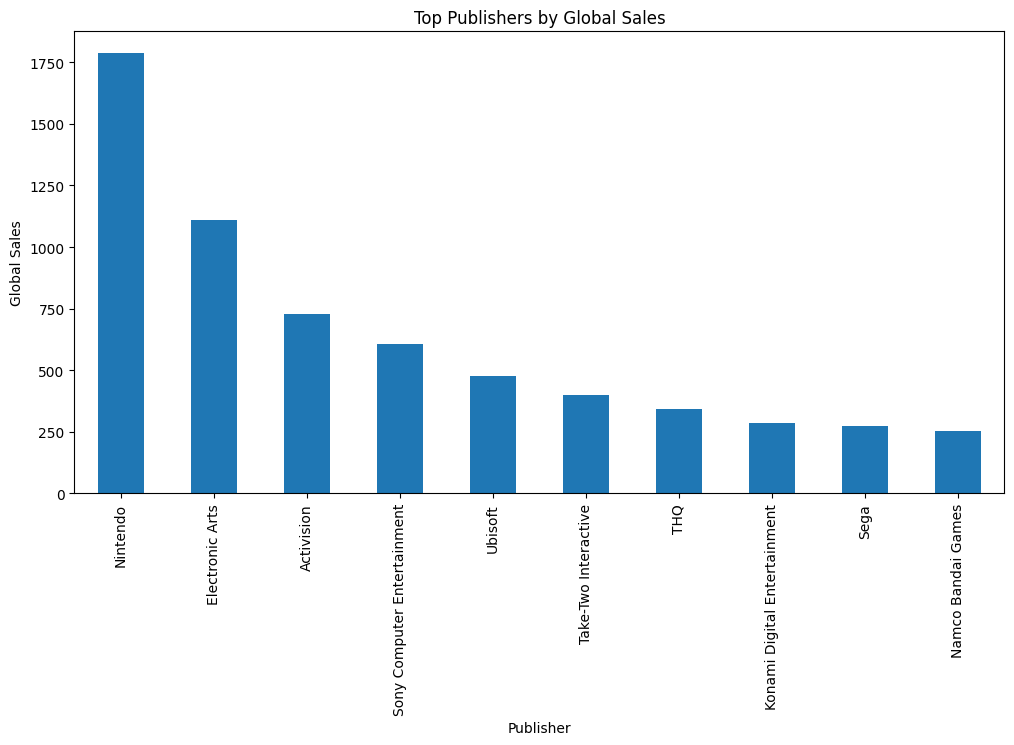

In [46]:
plt.figure(figsize=(12,6))

publisher_sales.plot(kind='bar')

plt.title("Top Publishers by Global Sales")

plt.ylabel("Global Sales")

plt.show()

In [47]:
## Q14. Which games are the top 10 best-sellers globally?
top_games = sales[
    ['Name', 'Global_Sales']
].sort_values(
    by='Global_Sales',
    ascending=False
).head(10)

top_games

,Name,Global_Sales
0,Wii Sports,82.74
1,Super Mario Bros.,40.24
2,Mario Kart Wii,35.82
3,Wii Sports Resort,33.00
4,Pokemon Red/Pokemon Blue,31.37
5,Tetris,30.26
6,New Super Mario Bros.,30.01
7,Wii Play,29.02
8,New Super Mario Bros. Wii,28.62
9,Duck Hunt,28.31


In [48]:
#15. How do regional sales compare for specific platforms?

platform_region = sales.groupby('Platform')[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
].sum().head(10)

platform_region

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Platform,,,,
2600,90.60,5.47,0.00,0.91
3DO,0.00,0.00,0.10,0.00
3DS,78.87,58.52,97.35,12.63
DC,5.43,1.69,8.56,0.27
DS,390.71,194.65,175.57,60.53
GB,114.32,47.82,85.12,8.20
GBA,187.54,75.25,47.33,7.73
GC,133.46,38.71,21.58,5.18
GEN,19.27,5.52,2.67,0.89


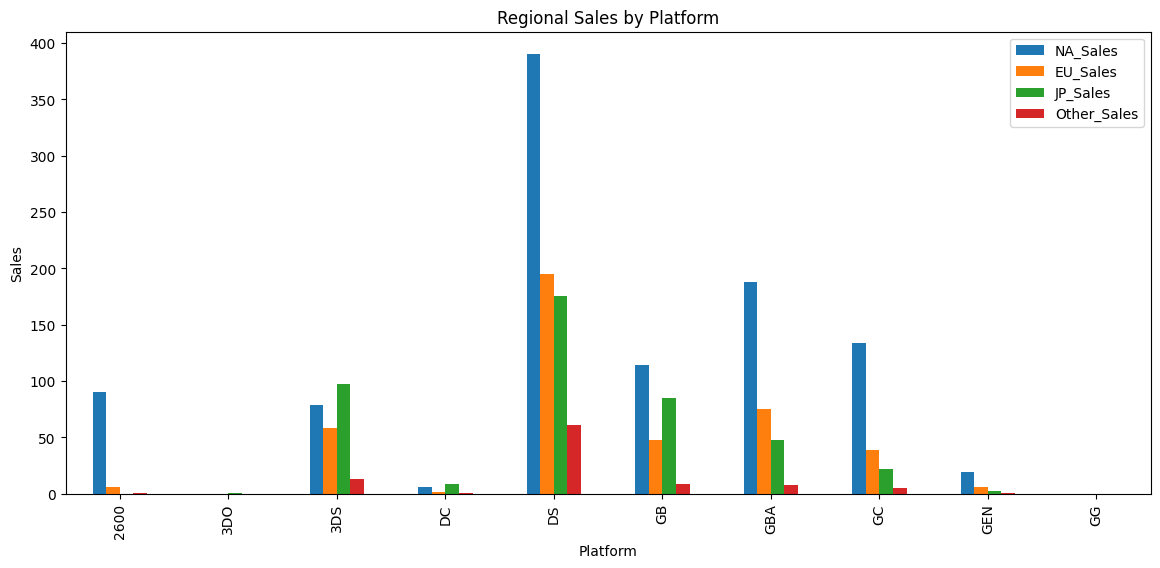

In [50]:
platform_region.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title("Regional Sales by Platform")

plt.ylabel("Sales")

plt.show()

In [51]:
#16. How has the market evolved by platform over time?

platform_year = sales.groupby(
    ['Year', 'Platform']
)['Global_Sales'].sum().unstack().fillna(0)

platform_year.tail()

Platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,N64,NES,NG,PC,PCFX,PS,PS2,PS3,PS4,PSP,PSV,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014.0,0.0,0.0,43.14,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.39,0.0,0.0,0.0,50.96,98.76,0.24,14.74,0.0,0.0,0.0,0.0,0.0,4.44,22.51,36.42,0.0,52.43
2015.0,0.0,0.0,26.99,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.07,0.0,0.0,0.0,18.22,115.30,0.12,7.10,0.0,0.0,0.0,0.0,0.0,1.55,16.38,13.05,0.0,57.66
2016.0,0.0,0.0,6.60,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.60,0.0,0.0,0.0,2.59,39.25,0.00,3.40,0.0,0.0,0.0,0.0,0.0,0.00,3.29,0.83,0.0,12.37
2017.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.03,0.00,0.02,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00
2020.0,0.0,0.0,0.00,0.0,0.29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00


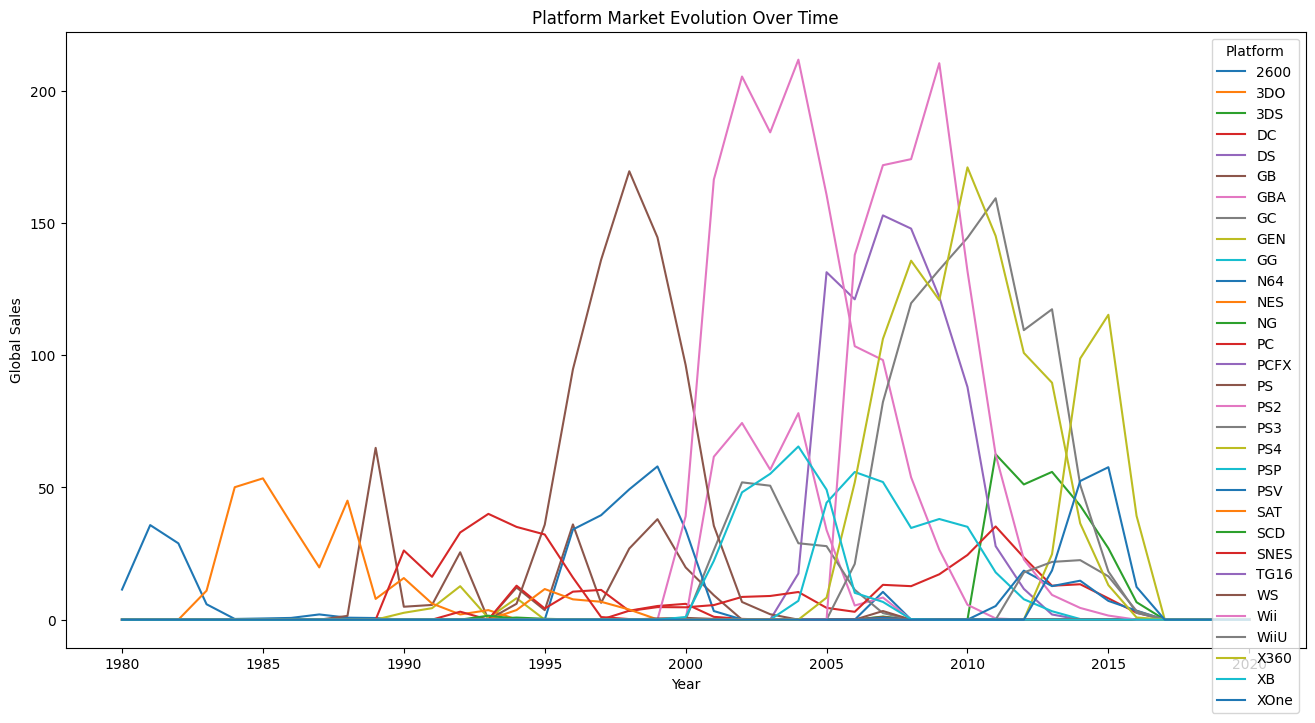

In [52]:
platform_year.plot(
    figsize=(16,8)
)

plt.title("Platform Market Evolution Over Time")

plt.ylabel("Global Sales")

plt.show()

In [53]:
#17. What are the regional genre preferences?

genre_region = sales.groupby('Genre')[
    ['NA_Sales', 'EU_Sales', 'JP_Sales']
].sum()

genre_region

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,877.83,525.00,159.95
Adventure,105.80,64.13,52.07
Fighting,223.59,101.32,87.35
Misc,410.24,215.98,107.76
Platform,447.05,201.63,130.77
Puzzle,123.78,50.78,57.31
Racing,359.42,238.39,56.69
Role-Playing,327.28,188.06,352.31
Shooter,582.60,313.27,38.28


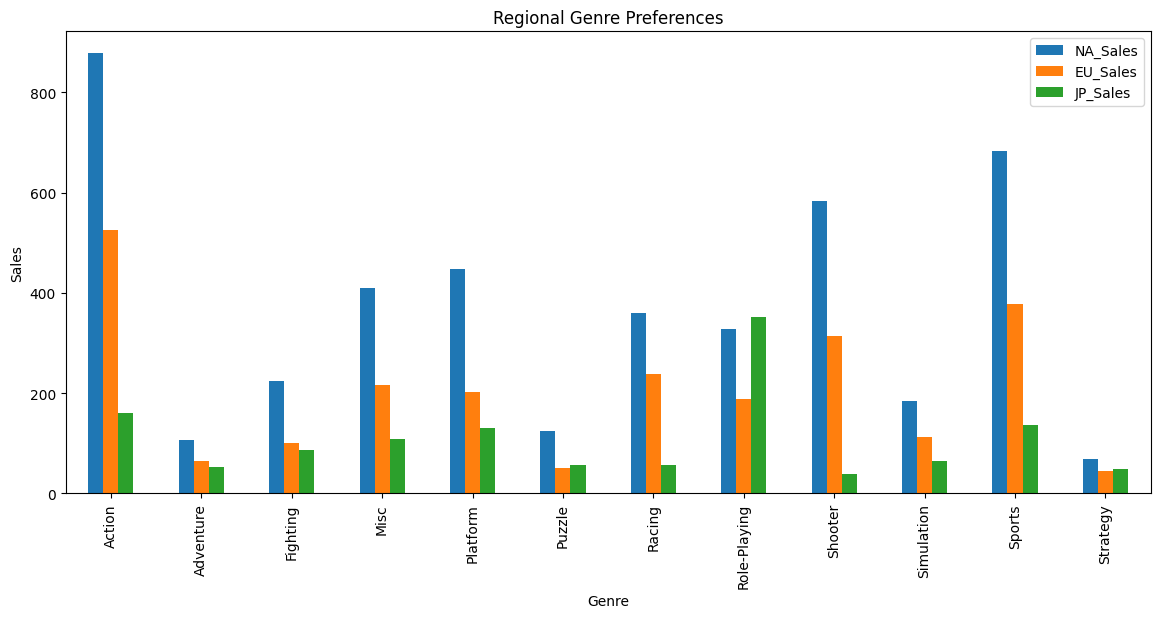

In [54]:
genre_region.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title("Regional Genre Preferences")

plt.ylabel("Sales")

plt.show()

In [55]:
#18. What’s the yearly sales change per region?

year_region = sales.groupby('Year')[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
].sum()

year_region.head()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Year,,,,
1980.0,10.59,0.67,0.00,0.12
1981.0,33.40,1.96,0.00,0.32
1982.0,26.92,1.65,0.00,0.31
1983.0,7.76,0.80,8.10,0.14
1984.0,33.28,2.10,14.27,0.70


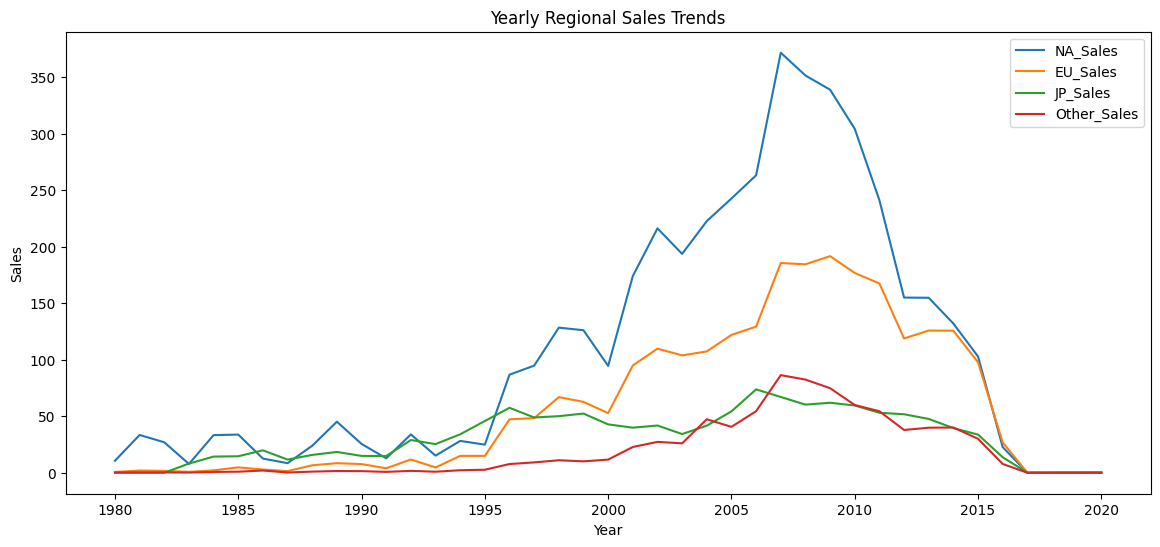

In [56]:
year_region.plot(
    figsize=(14,6)
)

plt.title("Yearly Regional Sales Trends")

plt.ylabel("Sales")

plt.show()

In [57]:
#19. What is the average sales per publisher?

avg_publisher_sales = sales.groupby('Publisher')[
    'Global_Sales'
].mean().sort_values(
    ascending=False
).head(10)

avg_publisher_sales

Publisher
Palcom                                4.170000
Red Orb                               2.620000
Nintendo                              2.541337
Arena Entertainment                   2.360000
UEP Systems                           2.250000
RedOctane                             2.170000
Valve                                 1.740000
Hello Games                           1.600000
Sony Computer Entertainment Europe    1.592667
Westwood Studios                      1.550000
Name: Global_Sales, dtype: float64

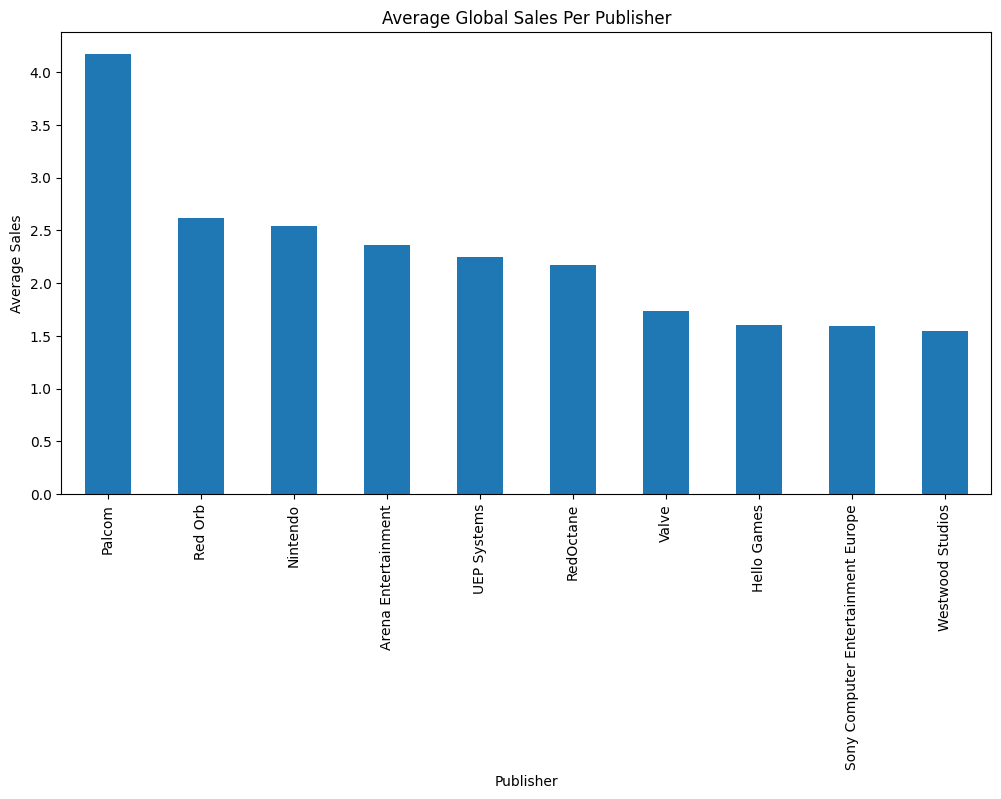

In [58]:
plt.figure(figsize=(12,6))

avg_publisher_sales.plot(kind='bar')

plt.title("Average Global Sales Per Publisher")

plt.ylabel("Average Sales")

plt.show()

In [60]:
#20. What are the top 5 best-selling games per platform?

top_platform_games = sales.groupby(
    ['Platform', 'Name']
)['Global_Sales'].sum().reset_index()

top_platform_games = top_platform_games.sort_values(
    ['Platform', 'Global_Sales'],
    ascending=[True, False]
)

top_platform_games.groupby('Platform').head(5)

,Platform,Name,Global_Sales
101,2600,Pac-Man,7.81
105,2600,Pitfall!,4.50
10,2600,Asteroids,4.31
94,2600,Missile Command,2.76
125,2600,Space Invaders,2.53
...,...,...,...
16403,XOne,Call of Duty: Black Ops 3,7.30
16402,XOne,Call of Duty: Advanced Warfare,5.13
16455,XOne,Grand Theft Auto V,5.08
16457,XOne,Halo 5: Guardians,4.26


Merged question

In [61]:
#21. Which game genres generate the most global sales?


genre_sales = merged.groupby('Genre')[
    'Global_Sales'
].sum().sort_values(
    ascending=False
)

genre_sales

Genre
Action          960.51
Platform        643.09
Shooter         532.48
Role-Playing    396.83
Sports          279.60
Racing          198.01
Puzzle          135.33
Misc            133.87
Fighting         87.06
Adventure        65.04
Simulation       35.06
Strategy         13.22
Name: Global_Sales, dtype: float64

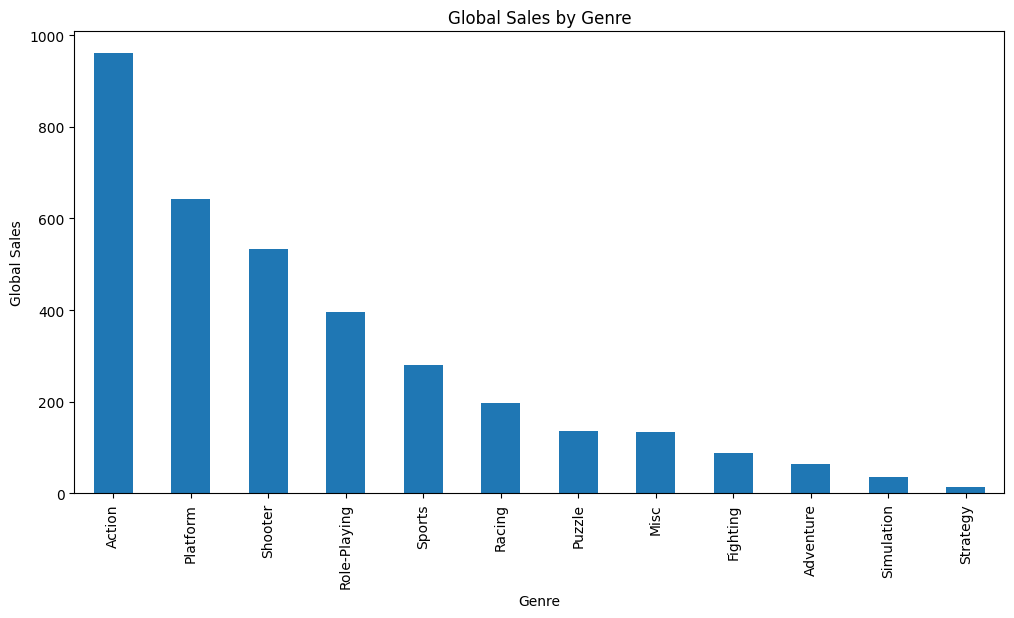

In [62]:
plt.figure(figsize=(12,6))

genre_sales.plot(kind='bar')

plt.title("Global Sales by Genre")

plt.ylabel("Global Sales")

plt.show()

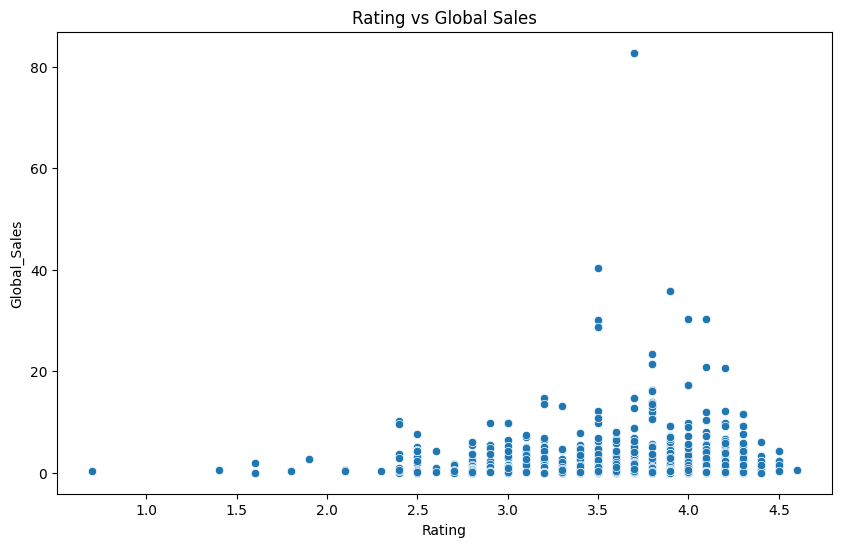

In [63]:
#22. How does user rating affect global sales?

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x='Rating',
    y='Global_Sales'
)

plt.title("Rating vs Global Sales")

plt.show()

In [64]:
#23. Which platforms have the most games with high ratings?

high_rated = merged[
    merged['Rating'] >= 4
]

platform_high = high_rated['Platform'].value_counts().head(10)

platform_high


Platform
PC      53
PS3     52
X360    48
PS2     46
PS      31
PS4     27
DS      22
SNES    21
GC      19
Wii     18
Name: count, dtype: int64

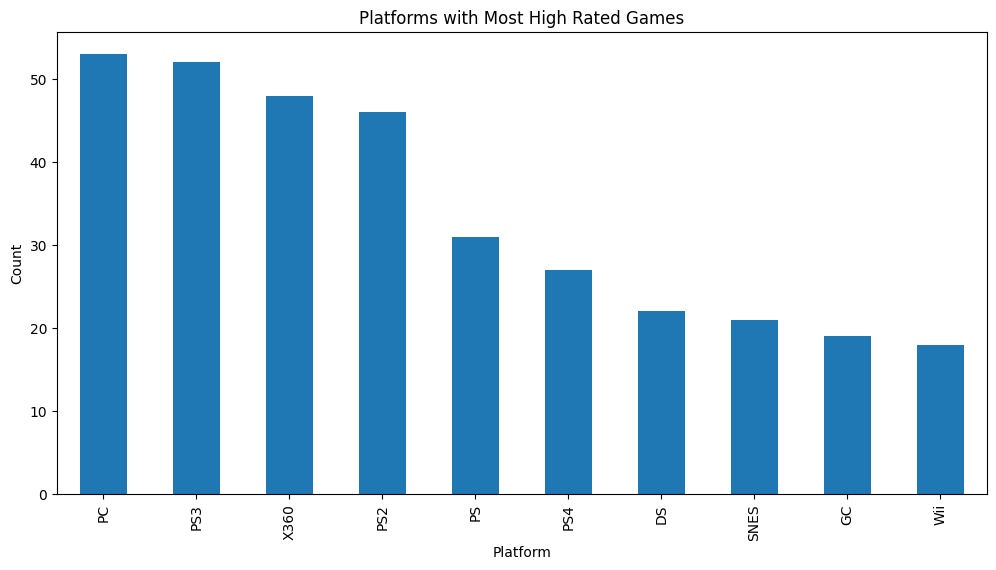

In [65]:
plt.figure(figsize=(12,6))

platform_high.plot(kind='bar')

plt.title("Platforms with Most High Rated Games")

plt.ylabel("Count")

plt.show()

In [66]:
#24. What’s the trend of releases and sales over time?

release_sales = merged.groupby('Release_Year')[
    'Global_Sales'
].sum()

release_sales

Release_Year
1980      9.03
1982      1.65
1985     45.31
1986     14.89
1987      5.19
1988     74.90
1989    110.54
1990     28.09
1991     39.73
1992     19.90
1993     23.10
1994     43.22
1995     33.11
1996     98.90
1997     54.39
1998     69.11
1999     49.94
2000     18.09
2001     74.26
2002     72.65
2003     28.83
2004     72.99
2005     91.56
2006    381.28
2007    160.18
2008    266.35
2009    180.92
2010    241.29
2011    304.05
2012    200.75
2013    339.87
2014     91.78
2015    102.76
2016     33.89
2017     24.68
2018     17.23
2019     30.81
2020     11.83
2022      0.96
2023     12.09
Name: Global_Sales, dtype: float64

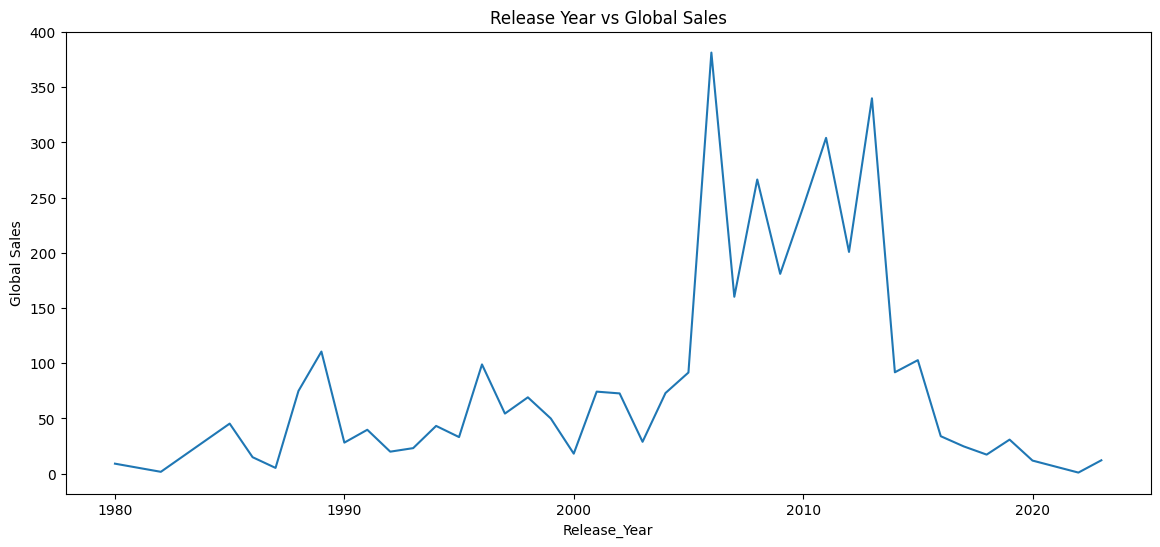

In [67]:
plt.figure(figsize=(14,6))

release_sales.plot()

plt.title("Release Year vs Global Sales")

plt.ylabel("Global Sales")

plt.show()

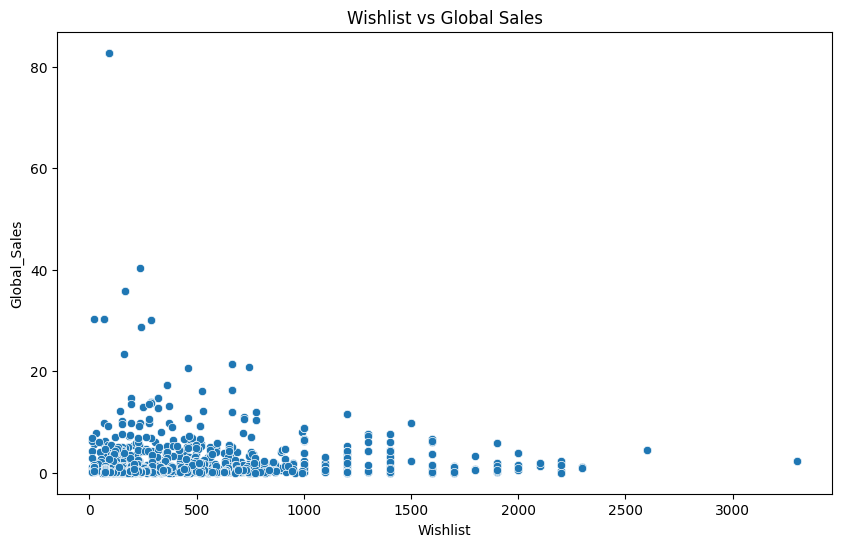

In [68]:
#25. Do highly wishlisted games lead to more sales?

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x='Wishlist',
    y='Global_Sales'
)

plt.title("Wishlist vs Global Sales")

plt.show()

In [69]:
#26. Which genres have the highest engagement but lowest sales?

genre_engagement = merged.groupby('Genre').agg({
    'Plays': 'mean',
    'Global_Sales': 'mean'
})

genre_engagement

,Plays,Global_Sales
Genre,,
Action,8801.050661,2.115661
Adventure,7276.701149,0.747586
Fighting,5171.428571,2.072857
Misc,15818.367347,2.732041
Platform,8129.496933,3.945337
Puzzle,4371.428571,6.444286
Racing,5984.615385,7.615769
Role-Playing,8049.808411,1.854346
Shooter,9694.642857,2.377143


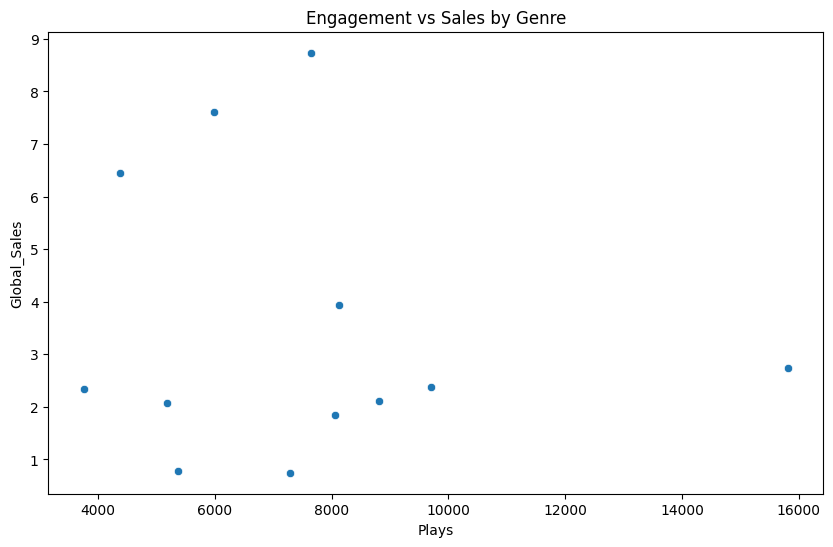

In [70]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=genre_engagement,
    x='Plays',
    y='Global_Sales'
)

plt.title("Engagement vs Sales by Genre")

plt.show()

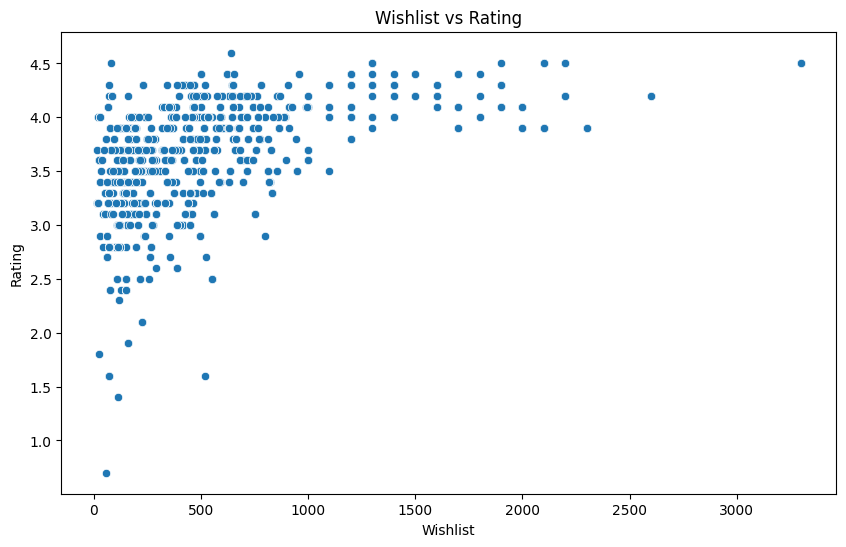

In [71]:
#27. Do highly wishlisted/backlogged games correlate with better ratings?

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x='Wishlist',
    y='Rating'
)

plt.title("Wishlist vs Rating")

plt.show()

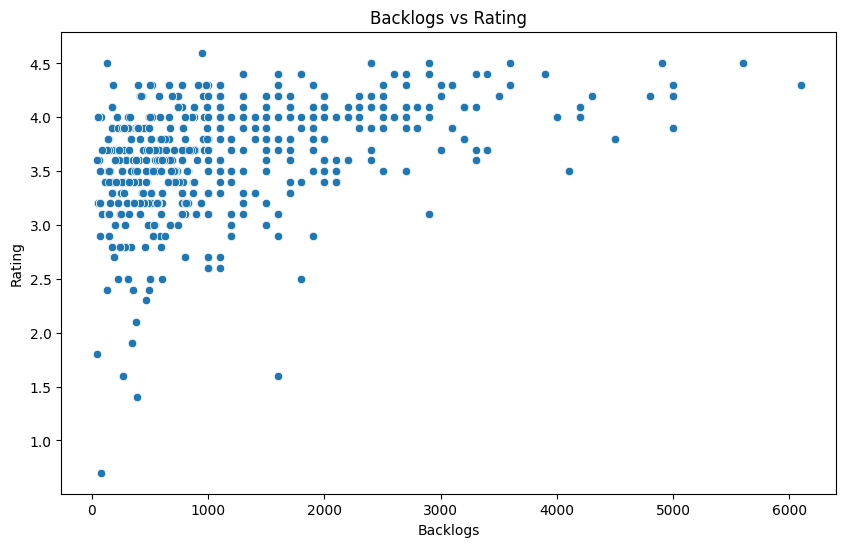

In [72]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x='Backlogs',
    y='Rating'
)

plt.title("Backlogs vs Rating")

plt.show()

In [73]:
#28. How does user engagement differ across genres?

genre_engage = merged.groupby('Genre')[
    ['Plays', 'Playing', 'Wishlist']
].mean()

genre_engage

,Plays,Playing,Wishlist
Genre,,,
Action,8801.050661,196.878855,734.572687
Adventure,7276.701149,140.666667,608.505747
Fighting,5171.428571,24.333333,120.761905
Misc,15818.367347,752.408163,176.285714
Platform,8129.496933,116.619632,469.883436
Puzzle,4371.428571,38.857143,204.095238
Racing,5984.615385,26.807692,121.961538
Role-Playing,8049.808411,310.214953,920.266355
Shooter,9694.642857,139.575893,492.656250


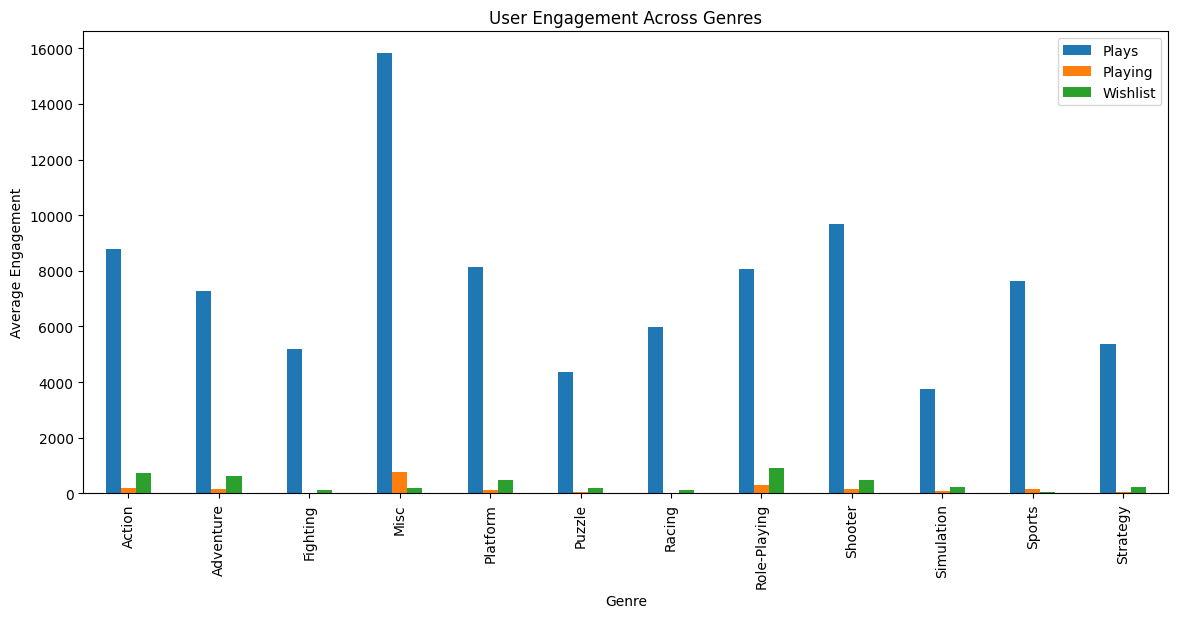

In [74]:
genre_engage.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title("User Engagement Across Genres")

plt.ylabel("Average Engagement")

plt.show()

In [75]:
#29. What are the top-performing combinations of Genre + Platform?

genre_platform = merged.groupby(
    ['Genre', 'Platform']
)['Global_Sales'].sum().sort_values(
    ascending=False
).head(10)

genre_platform

Genre     Platform
Sports    Wii         251.01
Action    PS3         240.01
Shooter   X360        220.97
Action    X360        173.85
Shooter   PS3         147.47
Action    PS2         143.35
Platform  Wii         137.02
Racing    Wii         107.94
Platform  NES         107.10
          DS          105.32
Name: Global_Sales, dtype: float64

In [76]:
#30. What does a regional sales heatmap by genre reveal?

heatmap_data = sales.groupby('Genre')[
    ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
].sum()

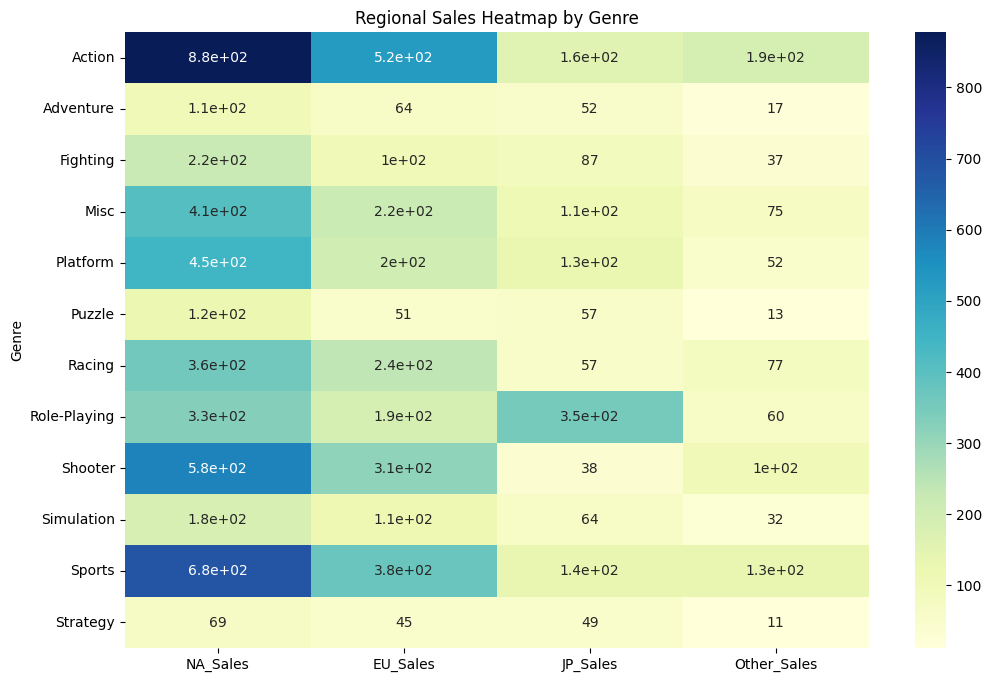

In [77]:
plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='YlGnBu'
)

plt.title("Regional Sales Heatmap by Genre")

plt.show()